In [1]:
import pandas as pd
import numpy as np
import re
import nltk
from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score,classification_report,confusion_matrix)
import matplotlib.pyplot as plt
import seaborn as sns
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [6]:
with open("/content/training.1600000.processed.noemoticon.csv", "r", encoding="latin-1") as f:
    for i in range(5):
        print(f.readline())

"0","1467810369","Mon Apr 06 22:19:45 PDT 2009","NO_QUERY","_TheSpecialOne_","@switchfoot http://twitpic.com/2y1zl - Awww, that's a bummer.  You shoulda got David Carr of Third Day to do it. ;D"

"0","1467810672","Mon Apr 06 22:19:49 PDT 2009","NO_QUERY","scotthamilton","is upset that he can't update his Facebook by texting it... and might cry as a result  School today also. Blah!"

"0","1467810917","Mon Apr 06 22:19:53 PDT 2009","NO_QUERY","mattycus","@Kenichan I dived many times for the ball. Managed to save 50%  The rest go out of bounds"

"0","1467811184","Mon Apr 06 22:19:57 PDT 2009","NO_QUERY","ElleCTF","my whole body feels itchy and like its on fire "

"0","1467811193","Mon Apr 06 22:19:57 PDT 2009","NO_QUERY","Karoli","@nationwideclass no, it's not behaving at all. i'm mad. why am i here? because I can't see you all over there. "



In [8]:
columns = ["target","id","date","flag","user","text"]
df = pd.read_csv("/content/training.1600000.processed.noemoticon.csv",encoding="latin-1",names=columns,engine="python",on_bad_lines="skip")
print(df.shape)
df.head()

(1600000, 6)


,target,id,date,flag,user,text
0,0,1467810369,Mon Apr 06 22:19:45 PDT 2009,NO_QUERY,_TheSpecialOne_,"@switchfoot http://twitpic.com/2y1zl - Awww, t..."
1,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...
2,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...
3,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire
4,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all...."


In [9]:
df = df[["target", "text"]]
df["target"] = df["target"].replace(4, 1)
print(df["target"].value_counts())

target
0    800000
1    800000
Name: count, dtype: int64


In [10]:
df = df.sample(n=50000,random_state=42)
print(df.shape)

(50000, 2)


In [12]:
import re
from nltk.corpus import stopwords
stop_words = set(stopwords.words("english"))
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"@\w+", "", text)
    text = re.sub(r"[^a-zA-Z ]", "", text)
    words = text.split()
    words = [
        word
        for word in words
        if word not in stop_words
    ]
    return " ".join(words)
df["clean_text"] = df["text"].apply(clean_text)
df.head()

,target,text,clean_text
541200,0,@chrishasboobs AHHH I HOPE YOUR OK!!!,ahhh hope ok
750,0,"@misstoriblack cool , i have no tweet apps fo...",cool tweet apps razr
766711,0,@TiannaChaos i know just family drama. its la...,know family drama lamehey next time u hang kim...
285055,0,School email won't open and I have geography ...,school email wont open geography stuff revise ...
705995,0,upper airways problem,upper airways problem


In [14]:
from sklearn.feature_extraction.text import TfidfVectorizer
vectorizer = TfidfVectorizer(max_features=5000)
X = vectorizer.fit_transform(df["clean_text"])
y = df["target"]
print(X.shape)

(50000, 5000)


In [15]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)
print(X_train.shape)
print(X_test.shape)

(40000, 5000)
(10000, 5000)


In [17]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=1000)
model.fit(X_train,y_train)

LogisticRegression(max_iter=1000)

In [21]:
predictions = model.predict(X_test)
print(predictions[:20])

[0 1 1 1 0 1 1 1 0 1 1 1 0 1 1 1 1 0 1 0]


In [22]:
from sklearn.metrics import accuracy_score, classification_report
accuracy = accuracy_score(y_test, predictions)
print("="*50)
print("MODEL PERFORMANCE")
print("="*50)
print(f"\nAccuracy: {accuracy*100:.2f}%\n")
print("Classification Report:\n")
print(classification_report(y_test, predictions))

MODEL PERFORMANCE

Accuracy: 75.62%

Classification Report:

              precision    recall  f1-score   support

           0       0.76      0.74      0.75      4977
           1       0.75      0.77      0.76      5023

    accuracy                           0.76     10000
   macro avg       0.76      0.76      0.76     10000
weighted avg       0.76      0.76      0.76     10000



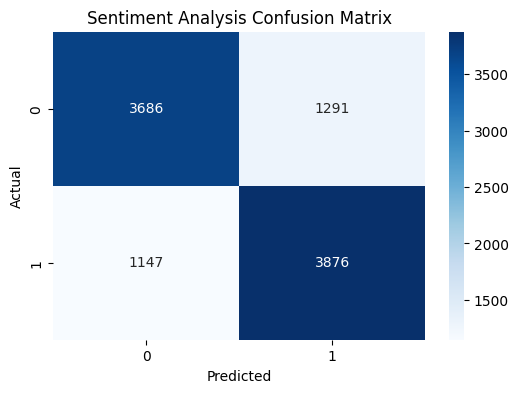

In [23]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, predictions)
plt.figure(figsize=(6,4))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Sentiment Analysis Confusion Matrix")
plt.show()

In [24]:
sample_tweet = ["I absolutely love this phone. The battery life is amazing!"]
sample_clean = [clean_text(sample_tweet[0])]
sample_vector = vectorizer.transform(sample_clean)
prediction = model.predict(sample_vector)
if prediction[0] == 1:
    print("😊 Positive Sentiment")
else:
    print("😠 Negative Sentiment")

😊 Positive Sentiment


In [25]:
sample_tweet = ["Worst customer service ever. Very disappointed."]
sample_clean = [clean_text(sample_tweet[0])]
sample_vector = vectorizer.transform(sample_clean)
prediction = model.predict(sample_vector)
if prediction[0] == 1:
    print("😊 Positive Sentiment")
else:
    print("😠 Negative Sentiment")

😠 Negative Sentiment


In [26]:
import pickle
pickle.dump(model,open("sentiment_model.pkl", "wb"))
pickle.dump(vectorizer,open("vectorizer.pkl", "wb"))
print("Model Saved Successfully!")

Model Saved Successfully!
